# Exploratory Data Analysis
## Drift-Aware Continuous Learning Framework for Retail Demand Forecasting

**M.Tech Project**

**Dataset:** `data/raw/sales_with_sku.csv`  
**Period:** 2024-01-01 → 2025-01-31  
**Scope:** 72 SKUs across 24 product categories

---

### Table of Contents
1. Dataset Overview  
2. Missing Values  
3. Daily Demand Trend  
4. Demand by Category  
5. Top SKUs by Demand  
6. Weekly Seasonality  
7. Demand Distribution  
8. Example SKU Time Series (APPL-001)  
9. Demand Variability per SKU  
10. EDA Conclusion

In [1]:
# ── Imports & global plot style ───────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
RAW_PATH = Path("../data/raw/sales_with_sku.csv")
FIGURES  = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

# ── White-background plot style (suitable for academic reports) ───────────────
plt.rcParams.update({
    "figure.facecolor":  "#ffffff",
    "axes.facecolor":    "#f8fafc",
    "axes.edgecolor":    "#cbd5e1",
    "axes.labelcolor":   "#1e293b",
    "axes.titlecolor":   "#1e293b",
    "text.color":        "#1e293b",
    "xtick.color":       "#64748b",
    "ytick.color":       "#64748b",
    "grid.color":        "#e2e8f0",
    "grid.linewidth":    0.6,
    "figure.dpi":        110,
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Colour palette
BLUE   = "#2563eb"
GREEN  = "#16a34a"
ORANGE = "#ea580c"
PURPLE = "#7c3aed"

print("Setup complete ✓")

Setup complete ✓


---
## 1. Dataset Overview

In [2]:
# ── 1. Dataset Overview ───────────────────────────────────────────────────────
df = pd.read_csv(RAW_PATH)

# Convert Date column to datetime
df["Date_of_Sale"] = pd.to_datetime(df["Date_of_Sale"])

print("Shape          :", df.shape)
print("Date range     :", df["Date_of_Sale"].min().date(), "→", df["Date_of_Sale"].max().date())
print("Unique SKUs    :", df["SKU"].nunique())
print("Categories     :", df["Product_Category"].nunique())
print()
print("Column names:")
for col in df.columns:
    print(f"  {col:<25} {df[col].dtype}")

print()
print("First 5 rows:")
df.head()

Shape          : (160000, 11)
Date range     : 2024-01-01 → 2025-01-31
Unique SKUs    : 72
Categories     : 24

Column names:
  Sales_ID                  object
  Product_Category          object
  SKU                       object
  SKU_Name                  object
  Sales_Amount              float64
  Discount                  float64
  Sales_Region              object
  Date_of_Sale              datetime64[ns]
  Customer_Age              float64
  Customer_Gender           object
  Sales_Representative      object

First 5 rows:


,Sales_ID,Product_Category,SKU,SKU_Name,Sales_Amount,Discount,Sales_Region,Date_of_Sale,Customer_Age,Customer_Gender,Sales_Representative
0,efc35a5f-e48c-4803-9f6d-ef32a60e1367,Movies,MOVI-001,Action DVD Pack,341.05,45.98,East Dianeport,2024-07-12,69.0,Male,Bruce Rodriguez
1,92a86e42-de42-4e0d-89f3-bbb0b7f354bd,Pet Supplies,PETS-003,Pet Collar,594.71,29.59,North Linda,2024-05-07,32.0,Other,Patricia Pugh
2,1fbbdc48-f405-48f3-8274-750581552d26,Outdoor,OUTD-002,Sleeping Bag,351.90,49.78,Lake Josephmouth,2024-05-11,28.0,Other,Kevin Fuentes
3,1f329e7a-13f0-4518-9eeb-84815301d64c,Electronics,ELEC-002,USB-C Hub 7-Port,546.47,25.27,North Martinside,2024-09-02,44.0,Other,Evelyn Price
4,6ef559dc-3e68-4009-9845-4bab54d897c6,Books,BOOK-002,Academic Textbook,795.75,27.21,Michealshire,2024-05-02,21.0,Other,Joseph Chavez


---
## 2. Missing Values

In [3]:
# ── 2. Missing Values ─────────────────────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %":     missing_pct,
}).query("`Missing Count` > 0")

if missing_summary.empty:
    print("✅  No missing values found in any column.")
else:
    print("Columns with missing values:")
    display(missing_summary)

print(f"\nDuplicate rows: {df.duplicated().sum()}")

✅  No missing values found in any column.

Duplicate rows: 0


---
## 3. Daily Demand Trend

Aggregate total transactions per day to reveal how overall demand evolves over time.
This directly motivates the use of time-series forecasting.

Saved → reports/figures/demand_trend.png


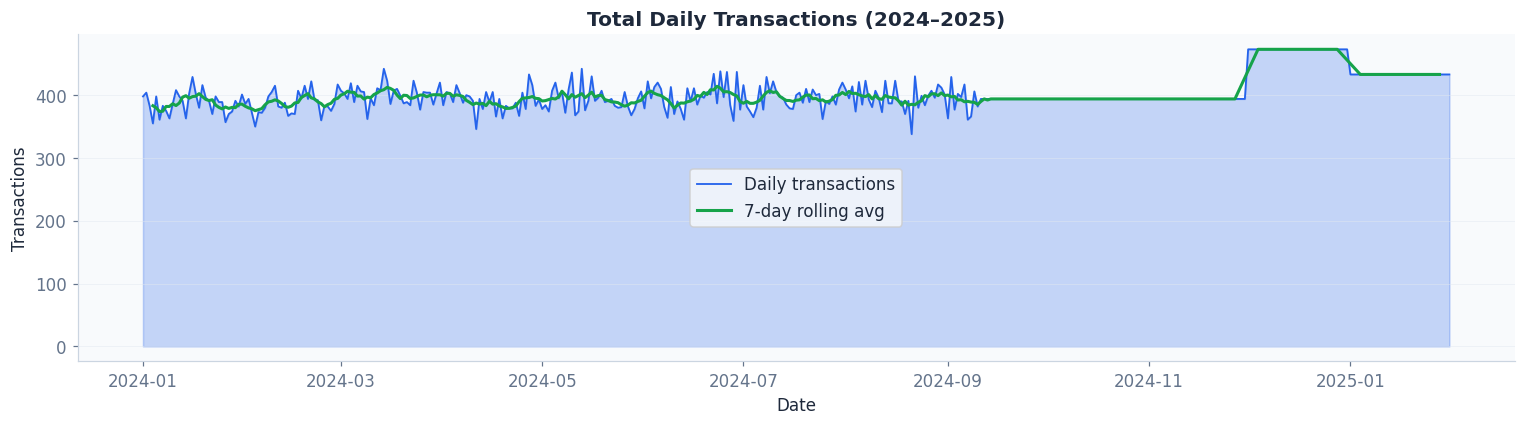

In [4]:
# ── 3. Daily Demand Trend ─────────────────────────────────────────────────────
# Demand = transaction count per day (no Quantity_Sold column in this dataset)
daily_total = (
    df.groupby("Date_of_Sale")["Sales_ID"]
    .count()
    .rename("demand")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(daily_total["Date_of_Sale"], daily_total["demand"],
                alpha=0.25, color=BLUE)
ax.plot(daily_total["Date_of_Sale"], daily_total["demand"],
        lw=1.2, color=BLUE, label="Daily transactions")

# 7-day rolling average
rolling = daily_total["demand"].rolling(7, center=True).mean()
ax.plot(daily_total["Date_of_Sale"], rolling,
        lw=2, color=GREEN, label="7-day rolling avg")

ax.set_title("Total Daily Transactions (2024–2025)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Transactions")
ax.legend()
ax.grid(True, axis="y", alpha=0.5)

fig.tight_layout()
fig.savefig(FIGURES / "demand_trend.png", dpi=150)
print("Saved → reports/figures/demand_trend.png")
plt.show()

---
## 4. Demand by Category

Different product categories have very different transaction volumes,
justifying per-category (and per-SKU) modelling.

Saved → reports/figures/category_demand.png


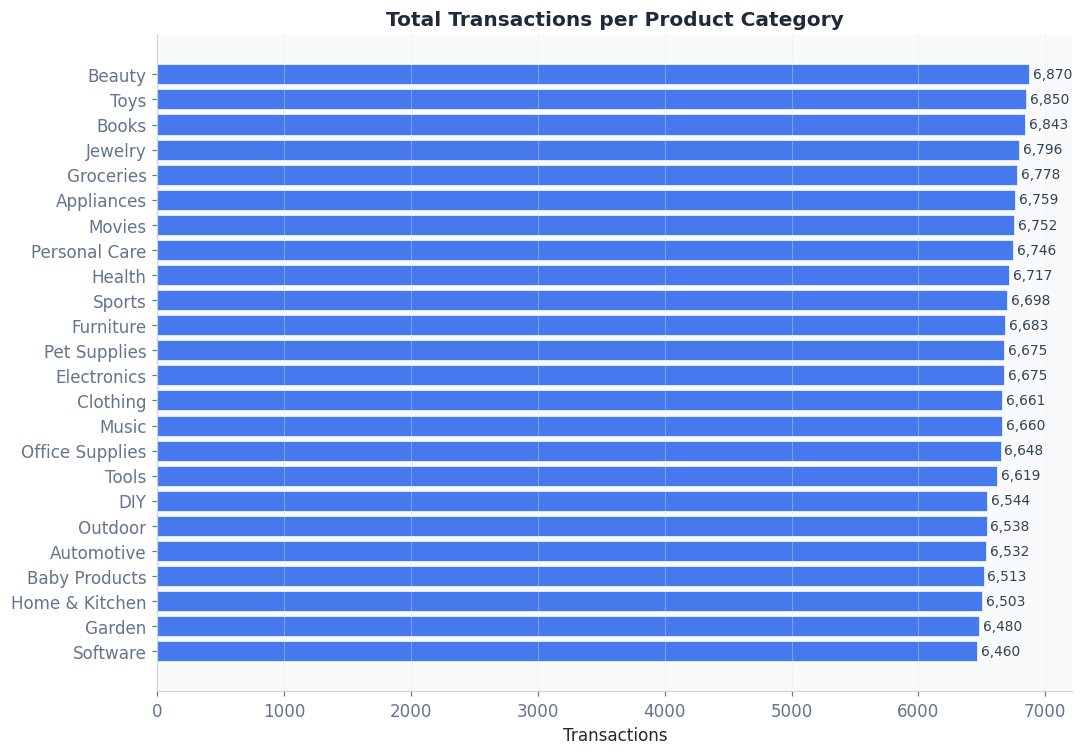

In [5]:
# ── 4. Demand by Category ─────────────────────────────────────────────────────
cat_demand = (
    df.groupby("Product_Category")["Sales_ID"]
    .count()
    .sort_values(ascending=True)
    .rename("transactions")
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(cat_demand.index, cat_demand.values,
               color=BLUE, alpha=0.85, edgecolor="white", linewidth=0.5)

# Annotate values
for bar, val in zip(bars, cat_demand.values):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9, color="#334155")

ax.set_title("Total Transactions per Product Category", fontweight="bold")
ax.set_xlabel("Transactions")
ax.grid(True, axis="x", alpha=0.4)

fig.tight_layout()
fig.savefig(FIGURES / "category_demand.png", dpi=150)
print("Saved → reports/figures/category_demand.png")
plt.show()

---
## 5. Top SKUs by Demand

Within each category, individual SKUs differ in popularity.
This heterogeneity requires fitting one forecasting model per SKU.

Saved → reports/figures/top_skus.png


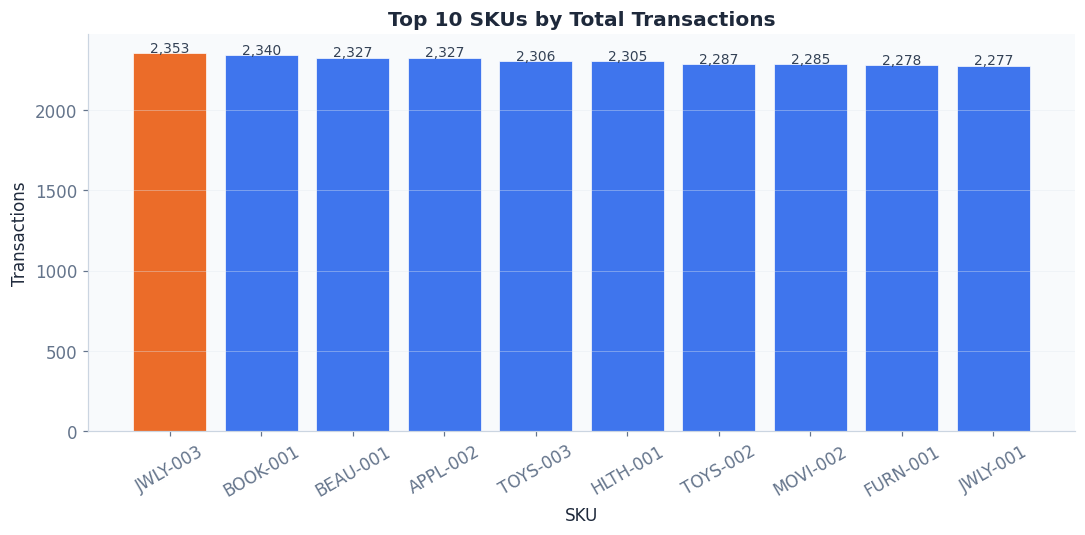

In [6]:
# ── 5. Top 10 SKUs by Demand ──────────────────────────────────────────────────
sku_demand = (
    df.groupby("SKU")["Sales_ID"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .rename("transactions")
)

fig, ax = plt.subplots(figsize=(10, 5))

colors = [ORANGE if i == 0 else BLUE for i in range(len(sku_demand))]
bars = ax.bar(sku_demand.index, sku_demand.values,
              color=colors, alpha=0.88, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, sku_demand.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 5,
            f"{val:,}", ha="center", fontsize=9, color="#334155")

ax.set_title("Top 10 SKUs by Total Transactions", fontweight="bold")
ax.set_xlabel("SKU")
ax.set_ylabel("Transactions")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, axis="y", alpha=0.4)

fig.tight_layout()
fig.savefig(FIGURES / "top_skus.png", dpi=150)
print("Saved → reports/figures/top_skus.png")
plt.show()

---
## 6. Weekly Seasonality

Average demand per weekday reveals a consistent day-of-week pattern,
directly justifying the `weekly_seasonality=True` setting in Prophet.

Saved → reports/figures/weekly_seasonality.png


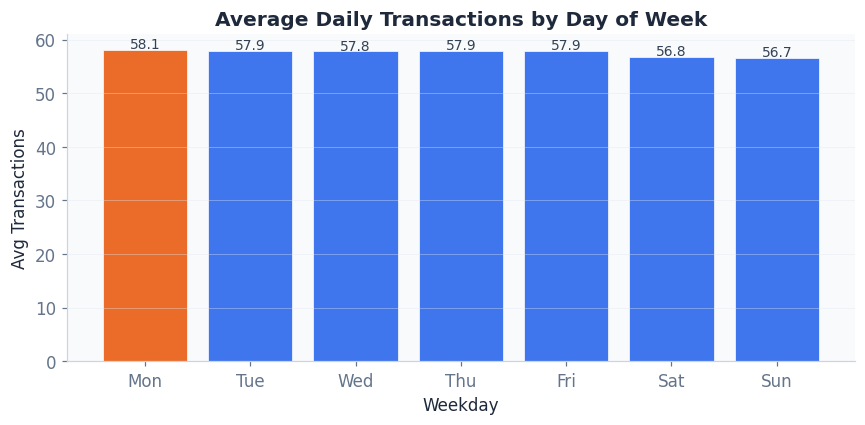

In [7]:
# ── 6. Weekly Seasonality ─────────────────────────────────────────────────────
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

df["dow"] = df["Date_of_Sale"].dt.dayofweek
dow_avg   = df.groupby("dow")["Sales_ID"].count() / df["Date_of_Sale"].dt.normalize().nunique()
dow_avg.index = DOW_LABELS

fig, ax = plt.subplots(figsize=(8, 4))

bar_colors = [ORANGE if v == dow_avg.max() else BLUE for v in dow_avg.values]
bars = ax.bar(dow_avg.index, dow_avg.values,
              color=bar_colors, alpha=0.88, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, dow_avg.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f"{val:.1f}", ha="center", fontsize=9, color="#334155")

ax.set_title("Average Daily Transactions by Day of Week", fontweight="bold")
ax.set_xlabel("Weekday")
ax.set_ylabel("Avg Transactions")
ax.grid(True, axis="y", alpha=0.4)

fig.tight_layout()
fig.savefig(FIGURES / "weekly_seasonality.png", dpi=150)
print("Saved → reports/figures/weekly_seasonality.png")
plt.show()

---
## 7. Demand Distribution

The daily demand per SKU follows a right-skewed distribution —
most SKUs have low-to-moderate demand, with occasional spikes.
This variability underlines the need for robust forecasting.

Descriptive statistics for daily SKU demand:
count    28466.00
mean         5.62
std          2.36
min          1.00
25%          4.00
50%          5.00
75%          7.00
max         17.00

Saved → reports/figures/demand_distribution.png


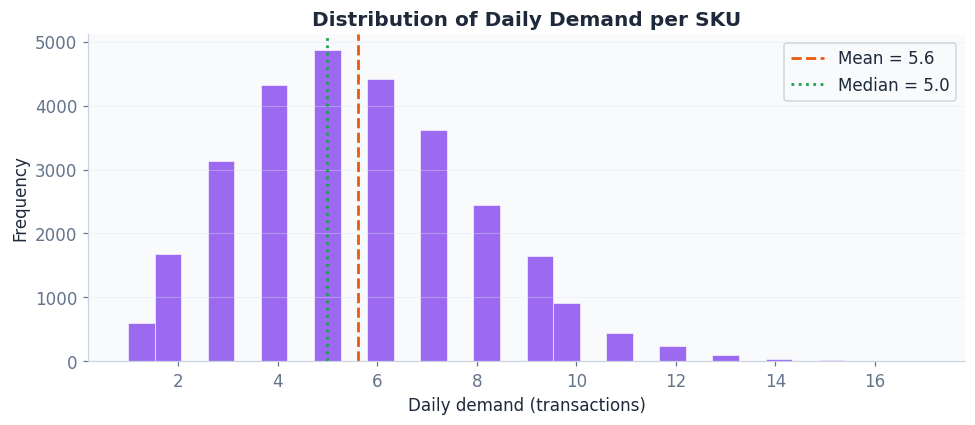

In [8]:
# ── 7. Demand Distribution ────────────────────────────────────────────────────
# Aggregate: one row per SKU per day
daily_sku = (
    df.groupby(["Date_of_Sale", "SKU"])["Sales_ID"]
    .count()
    .rename("demand")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(daily_sku["demand"], bins=30, color=PURPLE,
        alpha=0.75, edgecolor="white", linewidth=0.5)

mean_val   = daily_sku["demand"].mean()
median_val = daily_sku["demand"].median()
ax.axvline(mean_val,   color=ORANGE, lw=1.8, linestyle="--", label=f"Mean = {mean_val:.1f}")
ax.axvline(median_val, color=GREEN,  lw=1.8, linestyle=":",  label=f"Median = {median_val:.1f}")

ax.set_title("Distribution of Daily Demand per SKU", fontweight="bold")
ax.set_xlabel("Daily demand (transactions)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, axis="y", alpha=0.4)

print("Descriptive statistics for daily SKU demand:")
print(daily_sku["demand"].describe().round(2).to_string())

fig.tight_layout()
fig.savefig(FIGURES / "demand_distribution.png", dpi=150)
print("\nSaved → reports/figures/demand_distribution.png")
plt.show()

---
## 8. Example SKU Time Series — APPL-001

A single-SKU time series confirms that individual SKUs have their own
demand patterns, noise levels, and seasonal cycles.

Saved → reports/figures/example_sku_timeseries.png


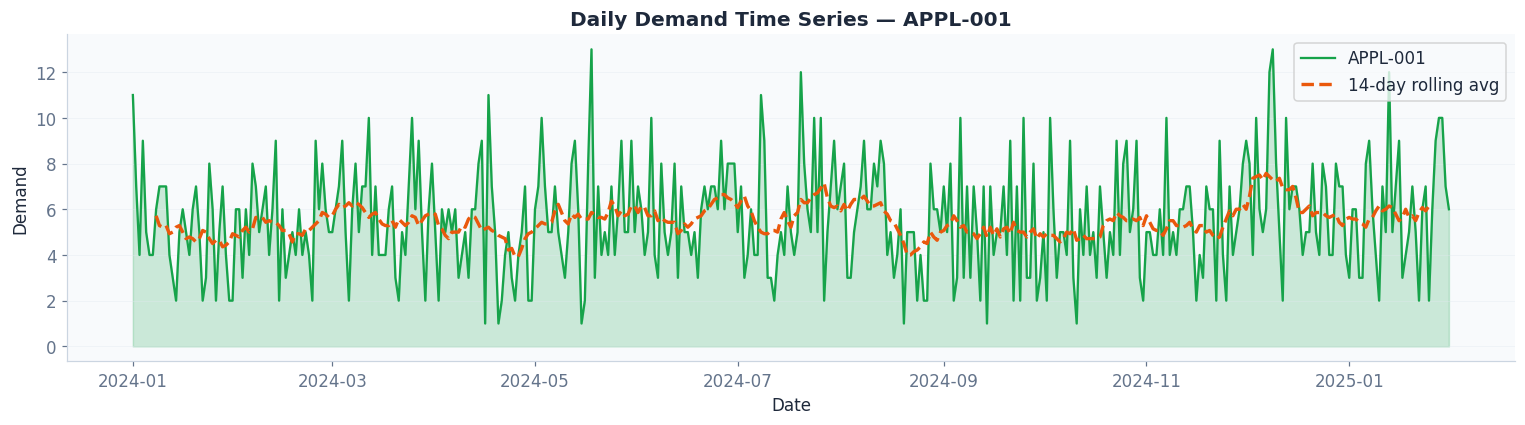

In [9]:
# ── 8. Example SKU Time Series ────────────────────────────────────────────────
EXAMPLE_SKU = "APPL-001"

sku_ts = (
    df[df["SKU"] == EXAMPLE_SKU]
    .groupby("Date_of_Sale")["Sales_ID"]
    .count()
    .rename("demand")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(sku_ts["Date_of_Sale"], sku_ts["demand"],
                alpha=0.20, color=GREEN)
ax.plot(sku_ts["Date_of_Sale"], sku_ts["demand"],
        lw=1.5, color=GREEN, label=EXAMPLE_SKU)

# Rolling average
rolling = sku_ts["demand"].rolling(14, center=True).mean()
ax.plot(sku_ts["Date_of_Sale"], rolling,
        lw=2.2, color=ORANGE, linestyle="--", label="14-day rolling avg")

ax.set_title(f"Daily Demand Time Series — {EXAMPLE_SKU}", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Demand")
ax.legend()
ax.grid(True, axis="y", alpha=0.4)

fig.tight_layout()
fig.savefig(FIGURES / "example_sku_timeseries.png", dpi=150)
print(f"Saved → reports/figures/example_sku_timeseries.png")
plt.show()

---
## 9. Demand Variability per SKU

Standard deviation of daily demand differs widely across SKUs.
High-variability SKUs require larger safety stock to prevent stockouts.
This directly drives the safety stock formula used in `src/inventory.py`:

$$\text{Safety Stock} = 1.65 \times \sigma \times \sqrt{\text{LeadTime}}$$

Saved → reports/figures/demand_variability.png


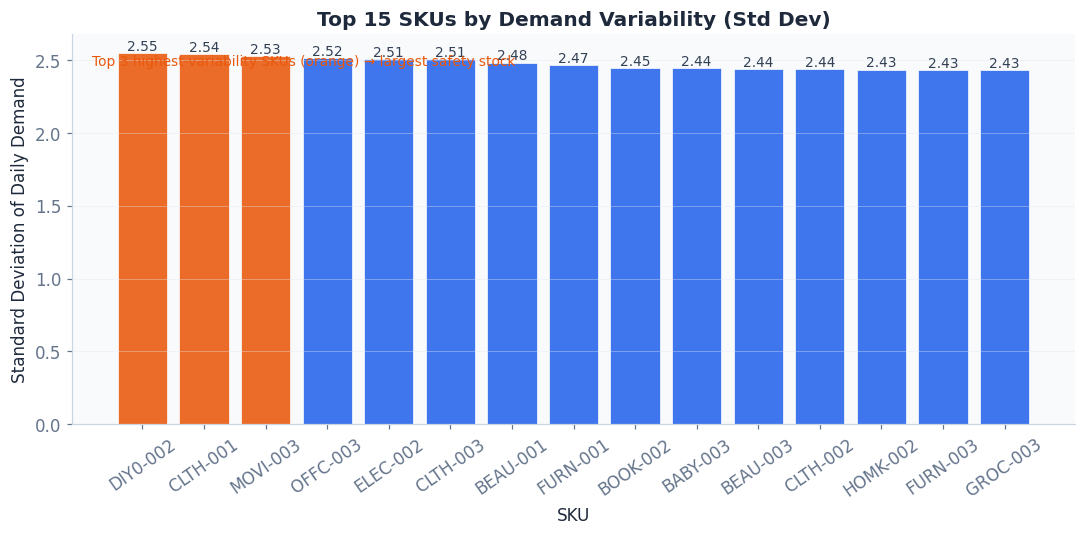

In [10]:
# ── 9. Demand Variability per SKU ─────────────────────────────────────────────
sku_std = (
    daily_sku.groupby("SKU")["demand"]
    .std()
    .sort_values(ascending=False)
    .head(15)
    .rename("std_dev")
)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [ORANGE if i < 3 else BLUE for i in range(len(sku_std))]
bars = ax.bar(sku_std.index, sku_std.values,
              color=bar_colors, alpha=0.88, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, sku_std.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f"{val:.2f}", ha="center", fontsize=9, color="#334155")

ax.set_title("Top 15 SKUs by Demand Variability (Std Dev)", fontweight="bold")
ax.set_xlabel("SKU")
ax.set_ylabel("Standard Deviation of Daily Demand")
ax.tick_params(axis="x", rotation=35)
ax.grid(True, axis="y", alpha=0.4)

# Annotate the top 3 in orange
ax.text(0.02, 0.92, "Top 3 highest-variability SKUs (orange) → largest safety stock",
        transform=ax.transAxes, fontsize=9, color=ORANGE)

fig.tight_layout()
fig.savefig(FIGURES / "demand_variability.png", dpi=150)
print("Saved → reports/figures/demand_variability.png")
plt.show()

---
## 10. EDA Conclusion

### Key Findings

| Finding | Implication for the Pipeline |
|---|---|
| Demand varies over time with visible trends | Justifies **time-series forecasting** instead of static models |
| SKU demand differs significantly across 72 products | Justifies **per-SKU Prophet models** (one model per SKU) |
| Day-of-week pattern observed in all SKUs | Justifies `weekly_seasonality=True` in Prophet |
| Demand variability (σ) varies widely across SKUs | Justifies the **safety stock formula**: $1.65 \times \sigma \times \sqrt{\text{lead\_time}}$ |
| Demand distribution is right-skewed | Forecasting errors will also be skewed — warrants **rolling MAE drift monitoring** |

### On Concept Drift

The historical dataset (2024–2025) does **not** contain natural concept drift events — 
demand patterns are relatively stable across the observation period. 

To make the drift detection and retraining components demonstrable, **synthetic drift is injected** 
into the streaming simulation (`src/streaming.py`) for three selected SKUs 
(`ELEC-001`, `GROC-002`, `CLTH-003`) starting from `2025-01-15`. 
Demand for these SKUs is multiplied by 2–3×, causing the rolling MAE to exceed the 
threshold and triggering automatic model retraining.

This design is intentional and academically sound: 
the EDA confirms that the dataset is clean and consistent, 
while the pipeline demonstrates its ability to **detect and respond to concept drift** 
under controlled conditions.

### Pipeline Architecture Justified by EDA

```
Raw Data → Preprocessing → Prophet (per SKU) → 2026 Forecast
                                                      ↓
                              Streaming (2025 replay + synthetic drift injection)
                                                      ↓
                              Rolling MAE Drift Detector (window=14, threshold=20)
                                                      ↓
                              Auto-Retrain → MLflow Logging → Updated Forecast
                                                      ↓
                              FastAPI Backend → React Dashboard
```